In [1]:
import sys
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
import cmasher as cmr
from astropy.visualization import quantity_support
quantity_support()

from cgm_ics.latexify import latexify
from cgm_ics import solve_ode as CF
from cgm_ics import HaloPotential as Halo
from cgm_ics import cooling_functions as Cool

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

import importlib # for testing : importlib.reload(module)

import pickle
from pathlib import Path

In [2]:
def save_solutions(solutions, filepath) -> None:
    """
    Save a list of CGMSolution objects to a file.
    
    Args:
        solutions: List of CGMSolution objects to save
        filepath: Path to save file (will add .pkl extension if not present)
    """
    filepath = Path(filepath)
    if filepath.suffix != '.pkl':
        filepath = filepath.with_suffix('.pkl')
    
    with open(filepath, 'wb') as f:
        pickle.dump(solutions, f)
    print(f"Saved {len(solutions)} solutions to {filepath}")

def load_solutions(filepath):
    """
    Load a list of CGMSolution objects from a file.
    
    Args:
        filepath: Path to the saved file
        
    Returns:
        List of CGMSolution objects
    """
    filepath = Path(filepath)
    if filepath.suffix != '.pkl':
        filepath = filepath.with_suffix('.pkl')
    
    with open(filepath, 'rb') as f:
        solutions = pickle.load(f)
    print(f"Loaded {len(solutions)} solutions from {filepath}")
    return solutions

In [3]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

# Set Halo Parameters
M_vir = 1.5e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82
      
print("Halo Mass: ",M_vir)
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)

Halo Mass:  150000000000.0 solMass
Virial Radius:  140.11663631147303 kpc
Virial Temperature:  172917.45740862112 K
Concentration Parameter:  10.123979369702292
R200m:  165.71726248723056 kpc
R200c:  112.11475881235687 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.681721382185353 kpc
Disk Scale Height 0.15 kpc


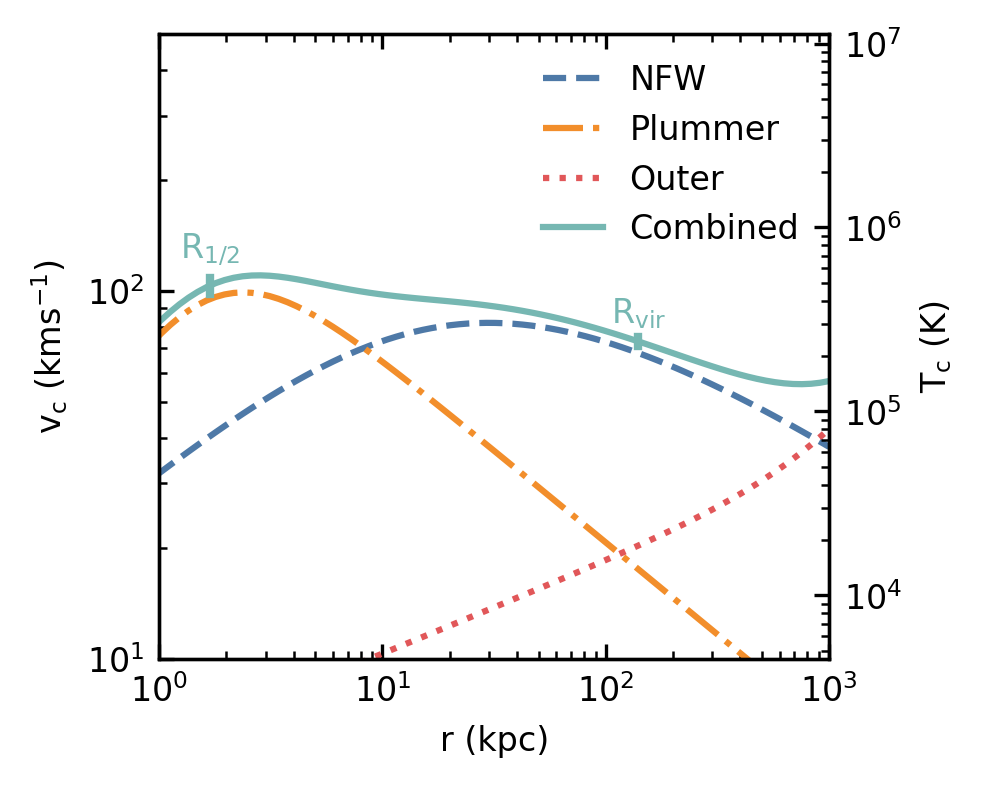

In [134]:
# Plot the circular velocity and its components
rs = np.logspace(-1,3,100) * un.kpc

cvs = nfw.vc(rs)
p_cvs = plummer.vc(rs)
o_cvs = outer.vc(rs)
c_cvs = combined.vc(rs)

latexify(columns=1)
plt.figure()
ax=plt.gca()
ax.tick_params(top=True, right=True, which="both", direction='in')
plt.yscale('log')
plt.xscale('log')
plt.xlim(1,1000)
plt.ylim(10,500)

plt.plot(rs,cvs,ls='--',label="NFW")
plt.plot(rs,p_cvs,ls='-.',label="Plummer")
plt.plot(rs,o_cvs,ls=':',label="Outer")
plt.plot(rs,c_cvs,ls='-',label="Combined")

tick_length = 2
ticks = [r_vir,r_200_m,r_200_c,r_gal]
tick_labels = [r'R$_{\rm vir}$', r'R$_{\rm 200m}$', r'R$_{\rm 200c}$', r'R$_{\rm 1/2}$']
label_dirs = [-3,1,1,1]

tick_length = 2
plt.plot([r_vir.value,r_vir.value], 
         [combined.vc(r_vir).value - tick_length, combined.vc(r_vir).value + tick_length], 
         color="C3", lw=2)
plt.text(r_vir.value,combined.vc(r_vir).value + tick_length * 2.5, r'R$_{\rm vir}$',
         color="C3", ha='center', va='bottom')

tick_length = 5
plt.plot([r_gal.value,r_gal.value], 
         [combined.vc(r_gal).value - tick_length, combined.vc(r_gal).value + tick_length], 
         color="C3", lw=2)
plt.text(r_gal.value,combined.vc(r_gal).value + tick_length * 2.5, r'R$_{\rm 1/2}$',
         color="C3", ha='center', va='bottom')

plt.xlabel('r (kpc)')
plt.ylabel(r'v$_{\rm c}$ (kms$^{-1}$)')
plt.legend(frameon=False, handlelength=1.8)

ax2 = ax.twinx() 
ax2.tick_params(which="both", direction='in')
ax2.set_yscale('log')
ax2.set_ylabel(r'T$_{\rm c}$ (K)') 
ax2.set_ylim(circular_temp(10*un.km/un.s),circular_temp(500*un.km/un.s))

plt.tight_layout()
plt.show()

In [4]:
# Set Cooling
cooling = Cool.Wiersma_Cooling(Z2Zsun=1.0/3,z=0)

In [5]:
r_ref = np.logspace(np.log10(0.01), np.log10(300), 500) * un.kpc
t_ff = (2**0.5 * r_ref / combined.vc(r_ref)).to('Gyr')
v_circ = combined.vc(r_ref).to('km/s')

In [6]:
combined2 = Halo.CombinedPotential(1e11*un.Msun, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)
v_circ2 = combined2.vc(r_ref).to('km/s')

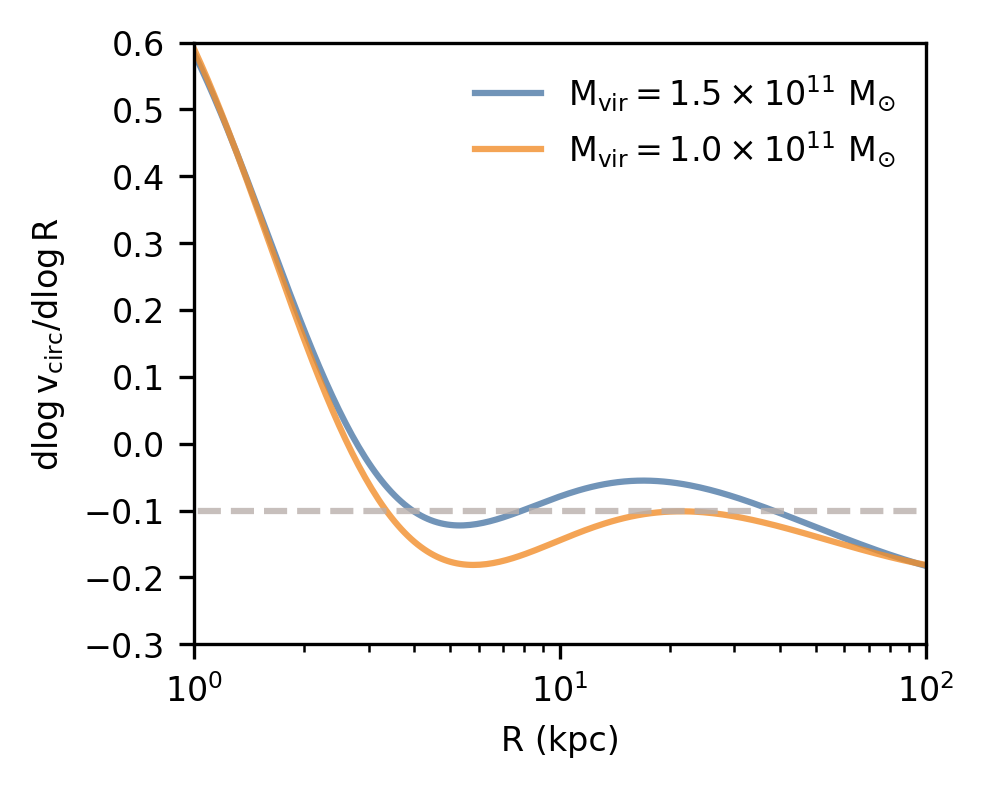

In [8]:
latexify(1)
plt.figure()

log_r = np.log10(r_ref.to('kpc').value)
log_v = np.log10(v_circ.to('km/s').value)
log_v2 = np.log10(v_circ2.to('km/s').value)

power_law_slope = np.gradient(log_v, log_r)
power_law_slope2 = np.gradient(log_v2, log_r)


plt.plot(r_ref.to('kpc').value, power_law_slope, alpha=0.8, label=r'M$_{\rm vir} = 1.5 \times 10^{11}$ M$_{\odot}$')
plt.plot(r_ref.to('kpc').value, power_law_slope2, alpha=0.8, label=r'M$_{\rm vir} = 1.0 \times 10^{11}$ M$_{\odot}$')


plt.hlines(-0.1,1e-1,1e2,colors='C9',ls='--',alpha=0.8)

plt.xscale('log')
plt.ylim(-0.3,0.6)
plt.xlim(1e0, 1e2)
plt.xlabel(r'R (kpc)')
plt.ylabel(r'd$\log$v$_{\rm circ}$/d$\log$R')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/vcirc_gradient.pdf',dpi=300)
plt.show()

In [152]:
R_sonics = [ 10.        ,  12.91549665,  16.68100537,  21.5443469 , 27.82559402 ,\
             35.93813664,  46.41588834,  59.94842503,  77.42636827, 100.        ]*un.kpc
R_max = [391,350,320,300,300,\
         300,300,293,274,253]*un.kpc

In [153]:
max_step = 0.01                            # lowest resolution of solution in ln(r)
R_min    = 0.15*un.kpc                      # inner radius of supersonic part of solution

transsonic_solutions = []
for i, R_sonic in enumerate(R_sonics):
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions.append(CF.shoot_from_R_sonic(combined,
                                                      cooling,
                                                      R_sonic,
                                                      R_max[i],
                                                      R_min,
                                                      max_step=max_step,
                                                      verbose=True))

R_sonic = 10.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Unbound (Maximum r = 17 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.250008 ... Stop reason: Unbound (Maximum r = 41 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.375006 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.312507 ... Stop reason: Unbound (Maximum r = 67 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.343757 ... Stop reason: Unbound (Maximum r = 111 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.359381 ... Stop reason: Sonic point (Maximum r = 56 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.351569 ... Stop reason: Sonic point (Maximum r = 381 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.347663 ... Stop reason: Unbound (Maximum r = 135 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.349616 ... Stop reason: Unbound (Maximum r = 162 kpc)
Integrating with v_

In [7]:
# transsonic_solutions = []
max_step = 0.01                            # lowest resolution of solution in ln(r)
R_min    = 0.15*un.kpc                      # inner radius of supersonic part of solution
temp_sonic_solutions = []
for R_sonic in [45]*un.kpc:
    print('R_sonic = %s'%R_sonic)
    temp_sonic_solutions.append(CF.shoot_from_R_sonic(combined,
                        cooling,
                        R_sonic,
                        291*un.kpc,
                        R_min,
                        max_step=max_step,
                        verbose=True))

R_sonic = 45.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Starts unbound
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.250008 ... Stop reason: Unbound (Maximum r = 61 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.375006 ... Stop reason: Unbound (Maximum r = 86 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.437506 ... Stop reason: Unbound (Maximum r = 120 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.468755 ... Stop reason: Unbound (Maximum r = 202 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.484380 ... Stop reason: Sonic point (Maximum r = 166 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.476568 ... Stop reason: Sonic point (Maximum r = 255 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.472662 ... Stop reason: Max R reached (Maximum r = 291 kpc)
Inward integration of supersonic part reached r = 0.150 kpc


In [141]:
# print(np.logspace(np.log10(0.6),np.log10(1.3),10)*un.kpc)
R_sonics2 = np.logspace(np.log10(1.0),np.log10(10),10)*un.kpc #sonic radii
R_max2 = 400*un.kpc # outer radius of integration

In [142]:
transsonic_solutions2 = []
for i, R_sonic in enumerate(R_sonics2):
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions2.append(CF.shoot_from_R_sonic(combined,
                                                      cooling,
                                                      R_sonics2[i],
                                                      R_max2,
                                                      R_min,
                                                      max_step=max_step,
                                                      verbose=True))

R_sonic = 1.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Sonic point (Maximum r = 1 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.500015 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.750012 ... Stop reason: Unbound (Maximum r = 6 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.875011 ... Stop reason: Sonic point (Maximum r = 12 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.812512 ... Stop reason: Unbound (Maximum r = 13 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.843762 ... Stop reason: Unbound (Maximum r = 29 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.859386 ... Stop reason: Sonic point (Maximum r = 285 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.851574 ... Stop reason: Unbound (Maximum r = 49 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.855480 ... Stop reason: Unbound (Maximum r = 77 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.857433 ... Stop reason: Unbound (Maximum r = 118 kpc)
Integrating

In [8]:
# Save
# save_solutions(transsonic_solutions, 'solutions/alt_my_cgm_solutions_1')

# Load
loaded_solutions = load_solutions('solutions/alt_my_cgm_solutions_1')

Loaded 10 solutions from solutions/alt_my_cgm_solutions_1.pkl


In [9]:
# Save
# save_solutions(transsonic_solutions2[:-1], 'solutions/alt_my_cgm_solutions_2')

# Load
loaded_solutions2 = load_solutions('solutions/alt_my_cgm_solutions_2')

Loaded 9 solutions from solutions/alt_my_cgm_solutions_2.pkl


1.3849028834935315 solMass / yr
1.518437382857145 solMass / yr
1.651694543826094 solMass / yr
1.755424871998542 solMass / yr
1.8168068255770875 solMass / yr
1.8762190161770682 solMass / yr
2.728608988699128 solMass / yr
2.1185921856917864 solMass / yr
2.2773694717320647 solMass / yr
2.4712844869813635 solMass / yr


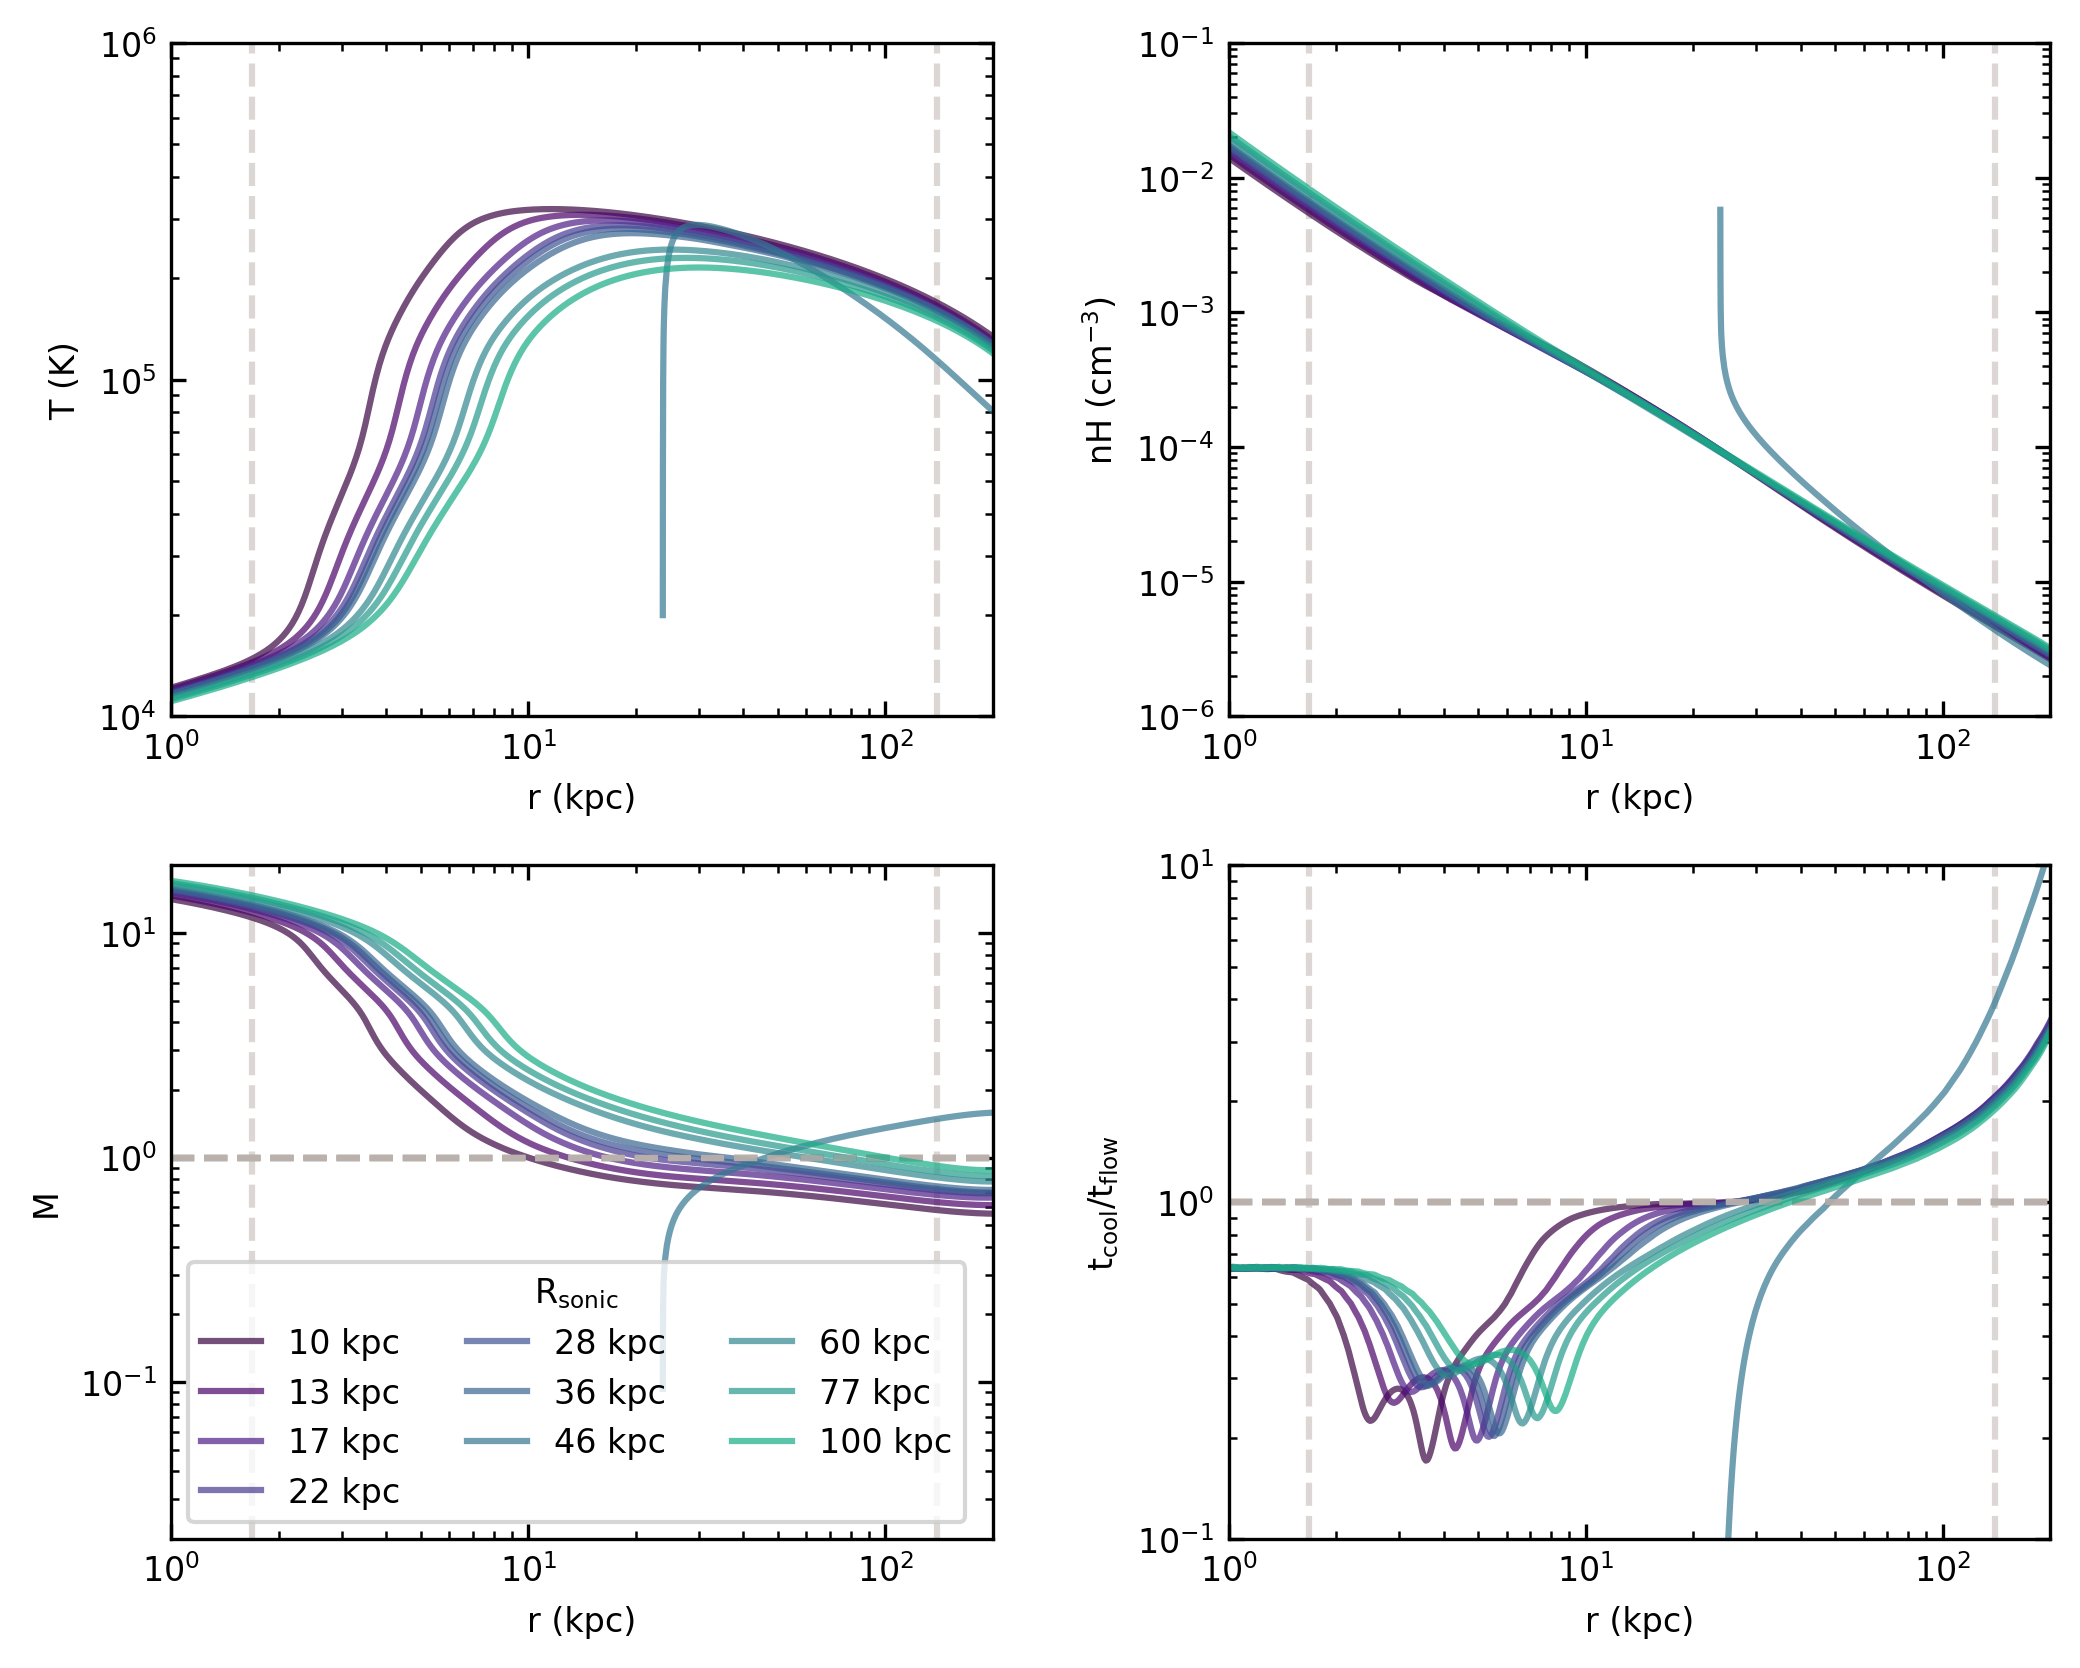

In [10]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(1e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i],
                       label=f'{res.R_sonic:.0f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i], 
                       label=f'{res.R_sonic:.0f}')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.02,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)

axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
# plt.savefig('./plots/cf_sols.pdf',dpi=300)
plt.show()

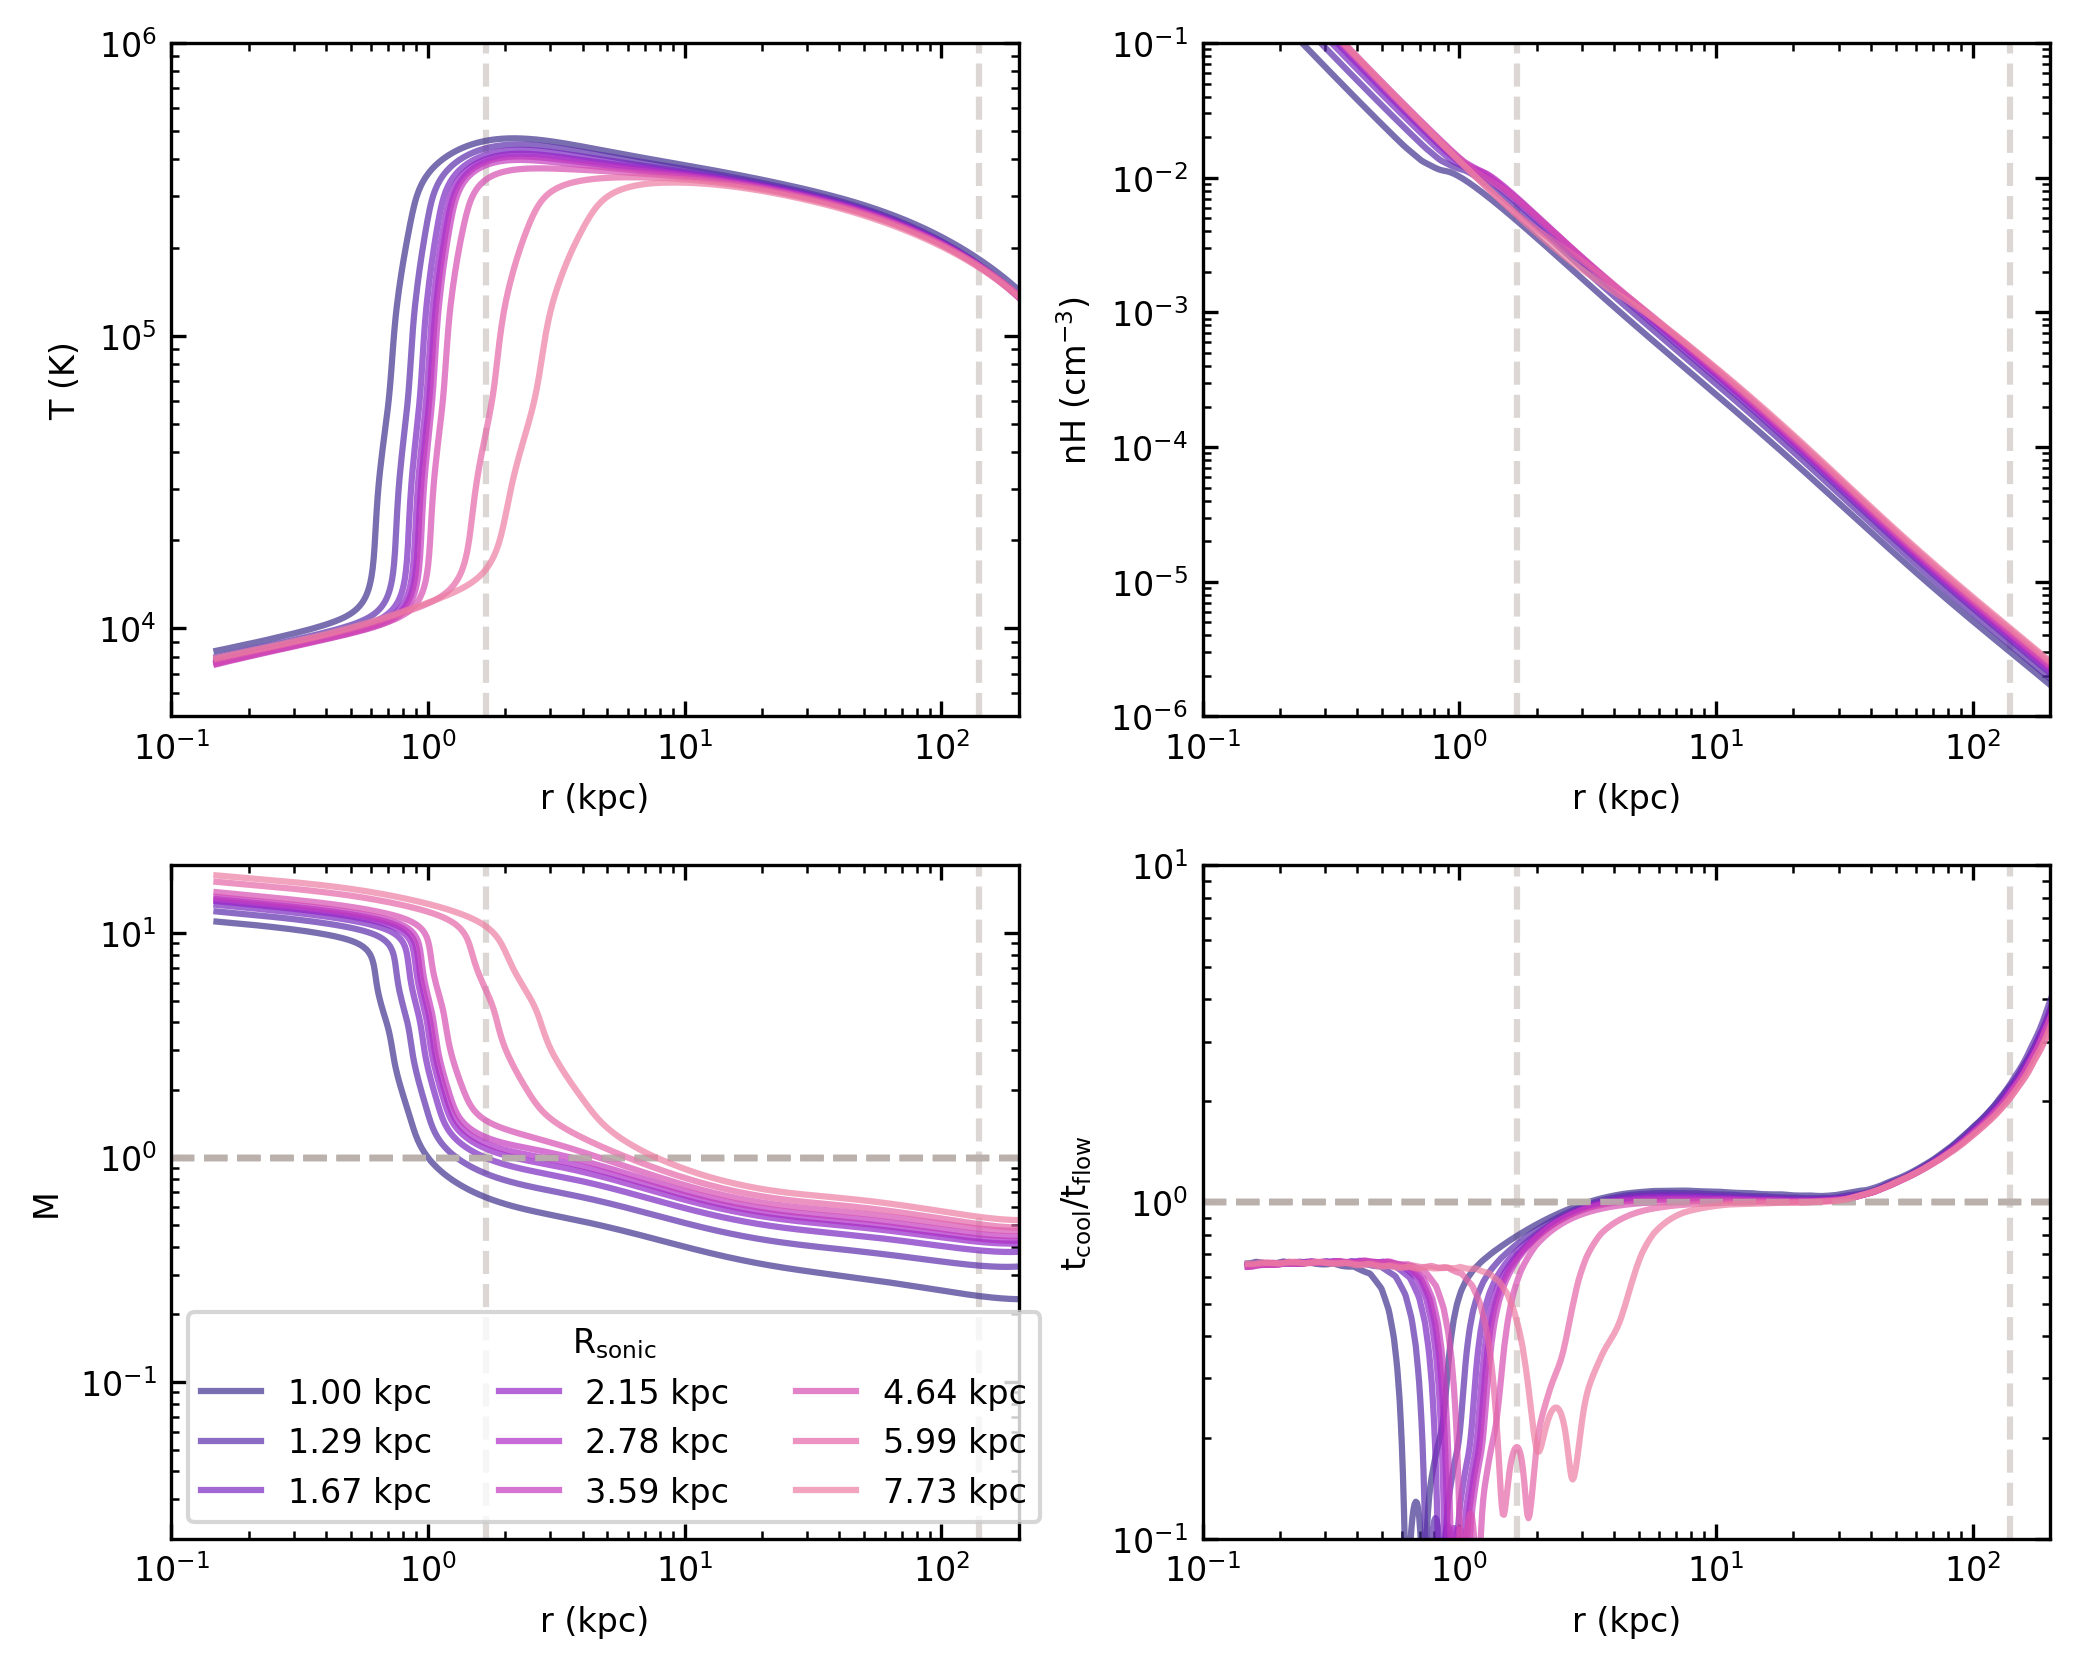

In [11]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(0.1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors2[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors2[i],
                       label=f'{res.R_sonic:.2f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors2[i], 
                       label=f'{res.R_sonic:.2f}')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.02,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors2[i])
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)

axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
plt.show()

1.3849028834935315 solMass / yr
1.2565319638023467 solMass / yr
1.9735643280427828 solMass / yr


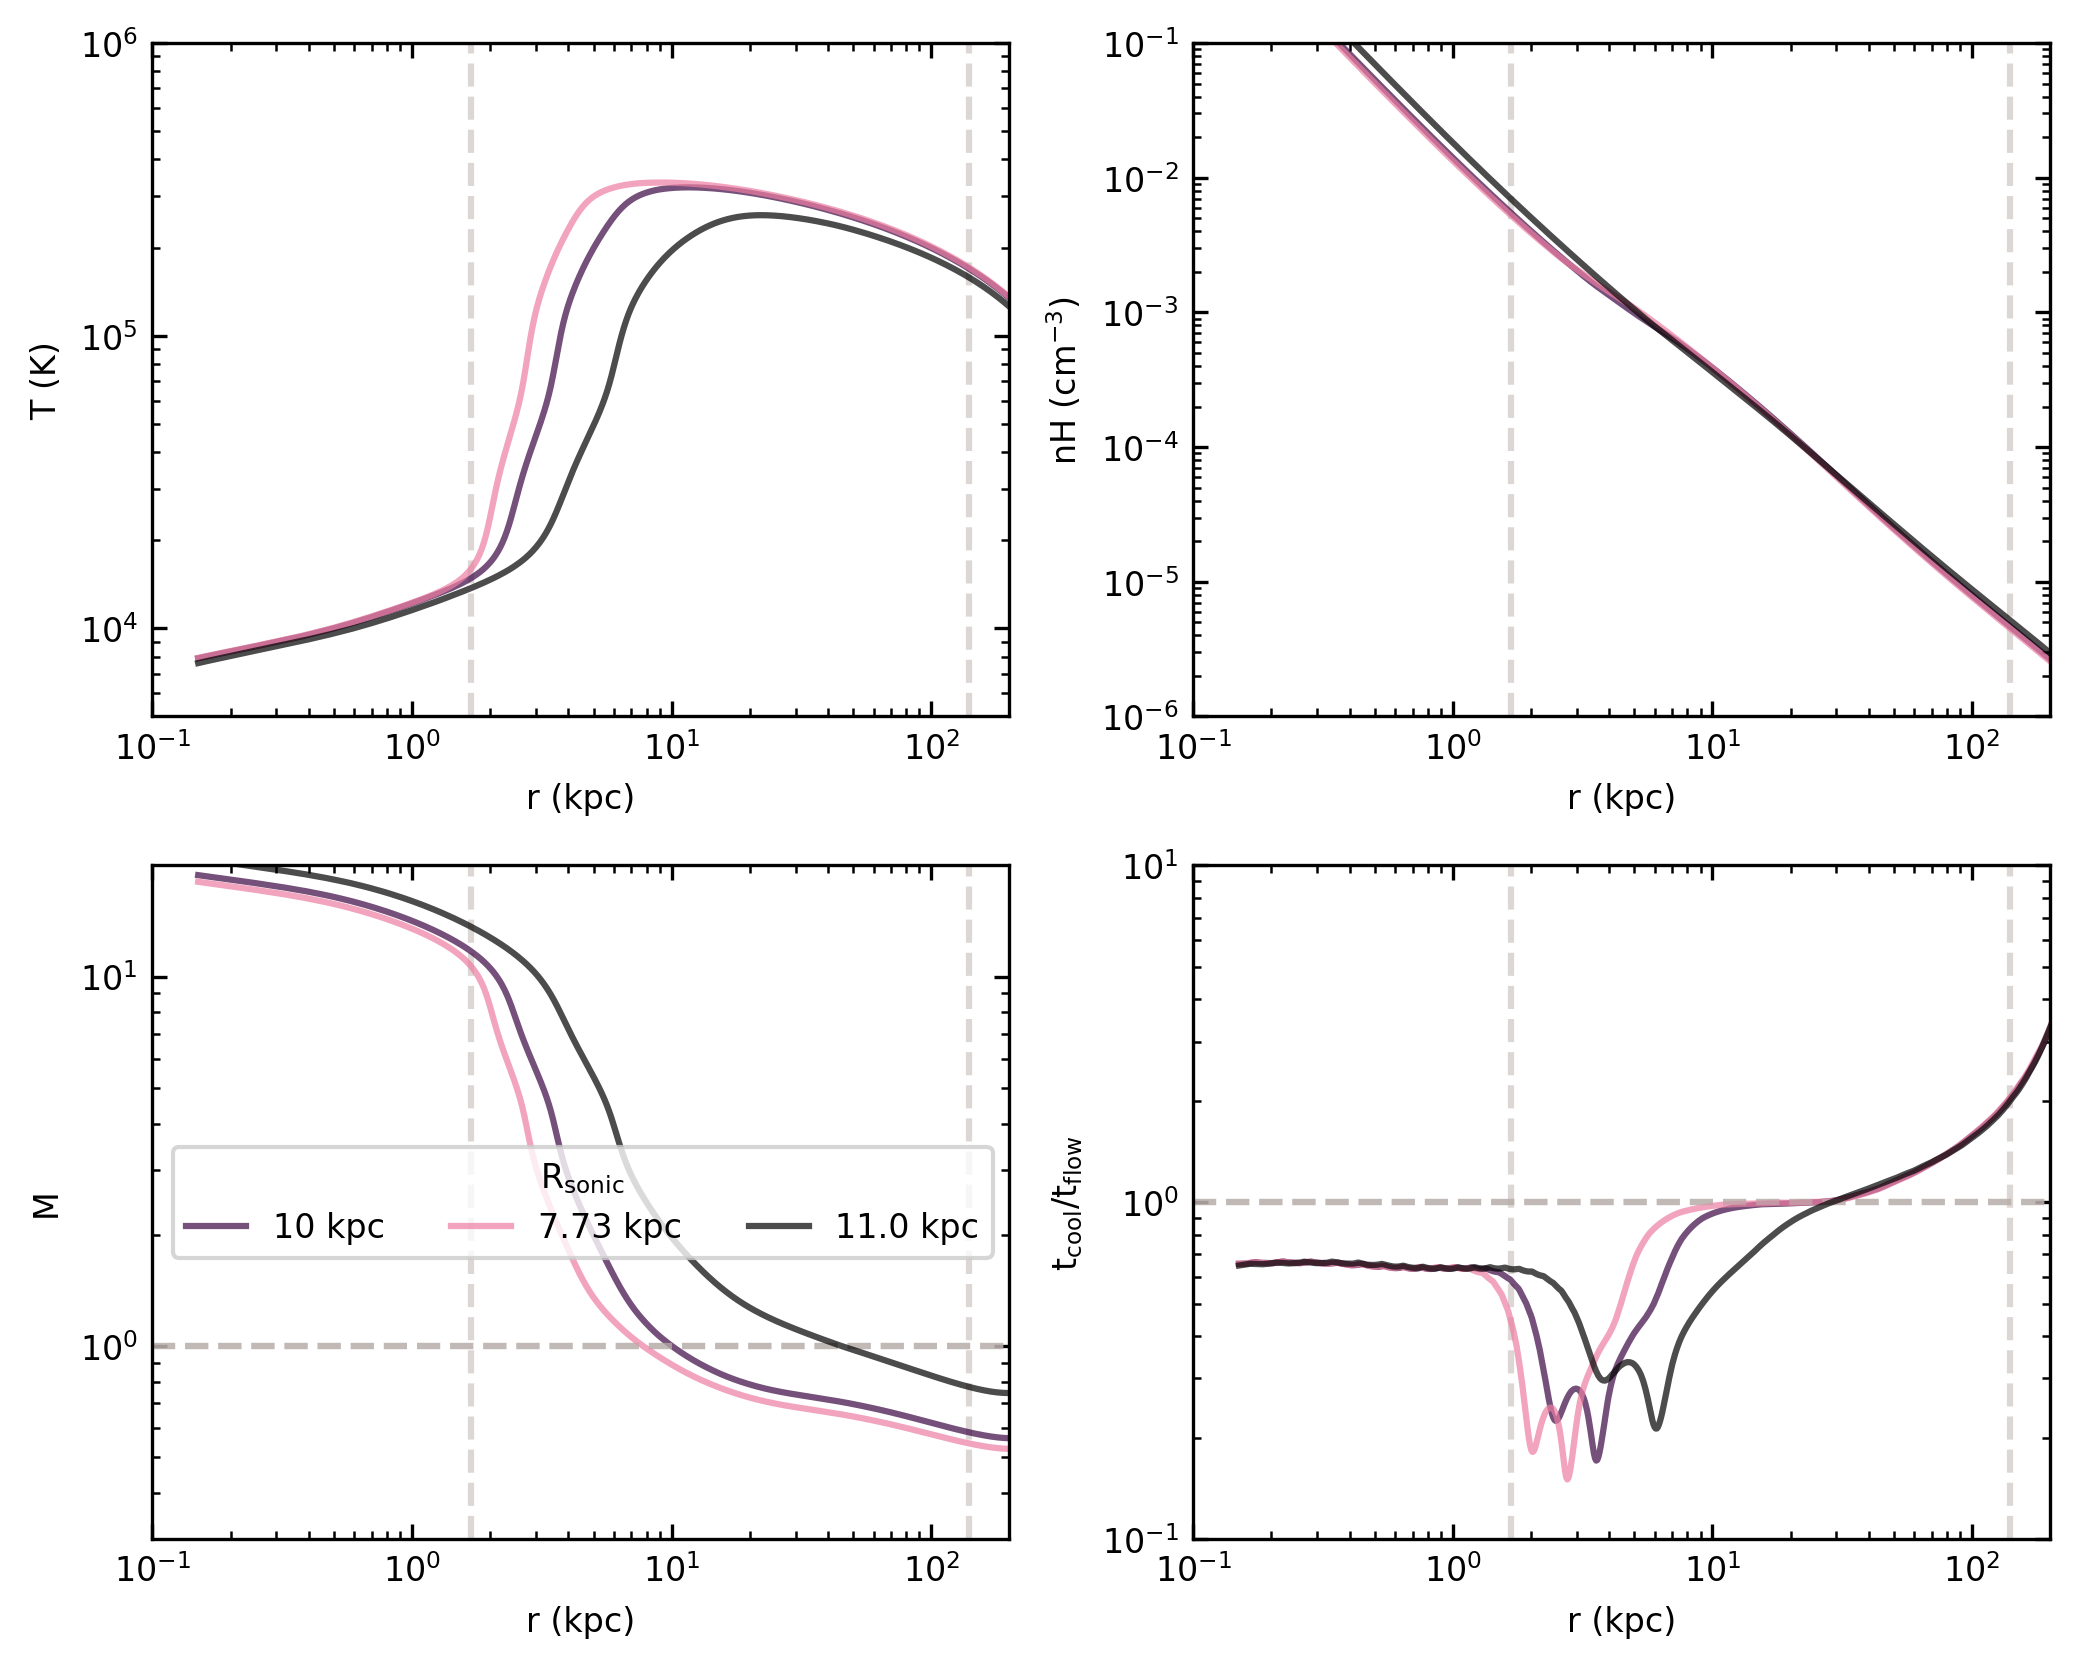

In [169]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(.1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
for i in [0]:
    res = loaded_solutions[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])

        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i],
                       label=f'{res.R_sonic:.0f}')

        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i], 
                       label=f'{res.R_sonic:.0f}')

        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])

        # print(res.mass_flow_rate)


colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))

for i in [-1]:
    res = loaded_solutions2[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors2[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors2[i],
                       label=f'{res.R_sonic:.2f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors2[i], 
                       label=f'{res.R_sonic:.2f}')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.3,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors2[i])
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)

for i in [-1]:
    res = temp_sonic_solutions[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color='black')
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color='black',
                       label=f'{res.R_sonic:.2f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color='black', 
                       label=f'11.0 kpc')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.3,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color='black')
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)


axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
plt.show()

1.2565319638023467 solMass / yr


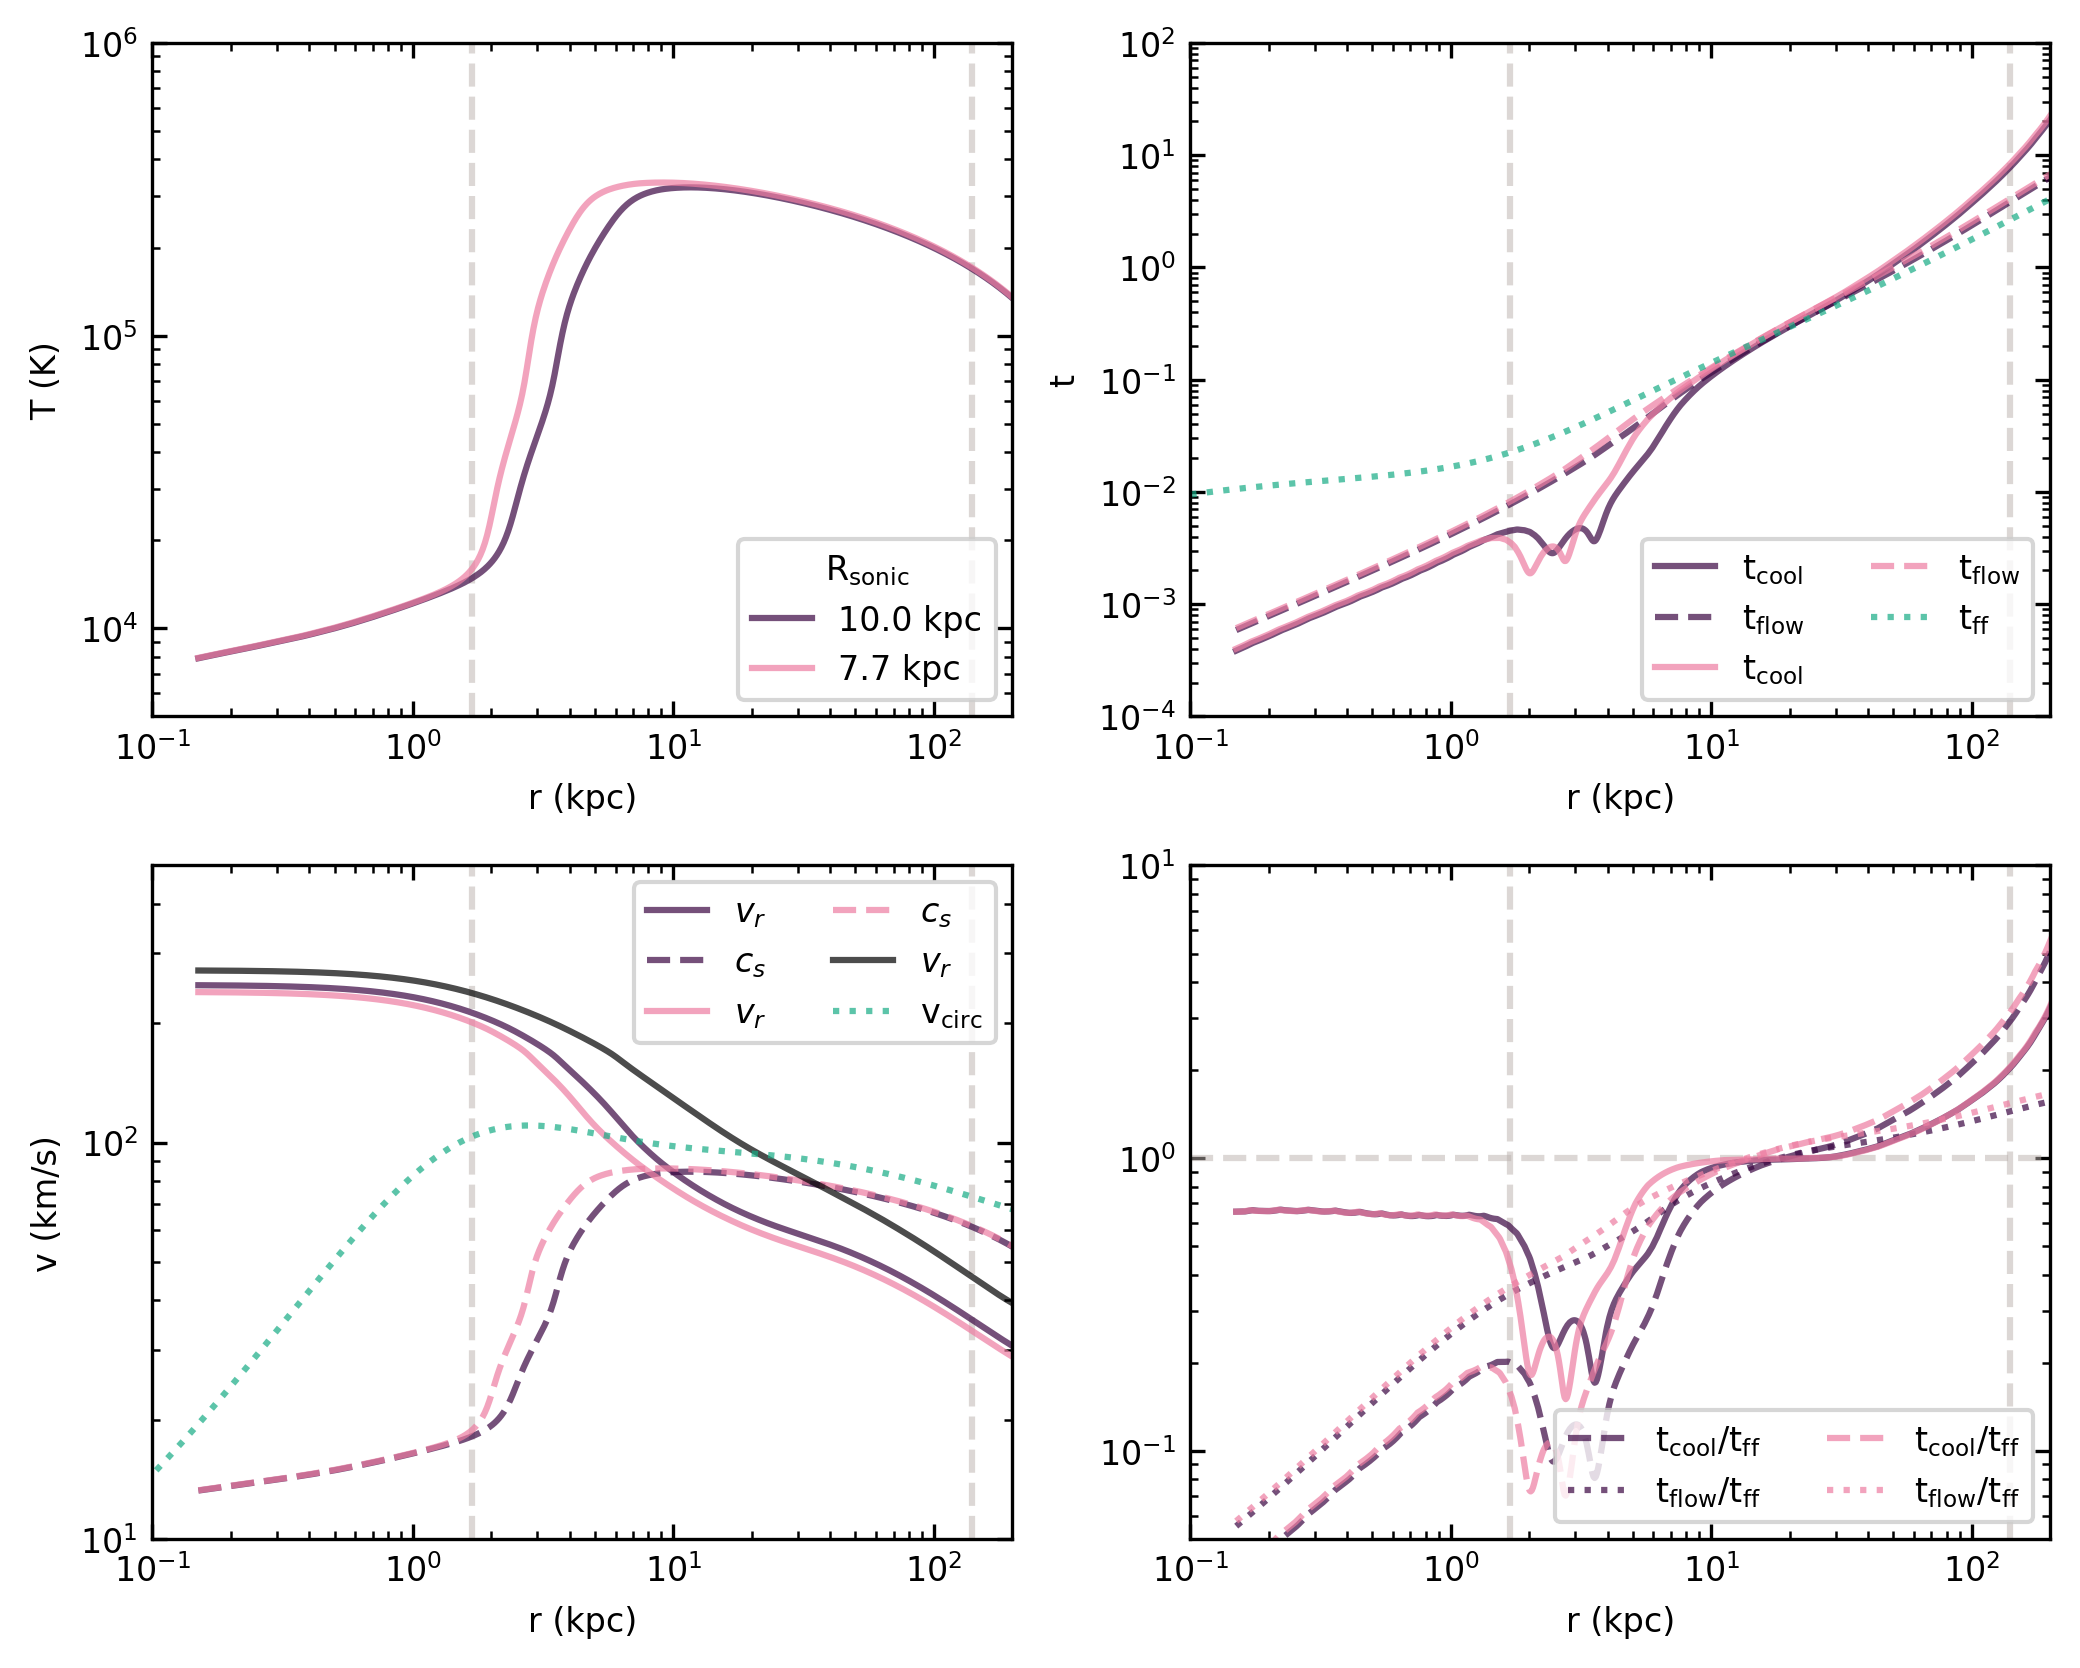

In [15]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(0.1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)


colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
for i in [0]:
    res = loaded_solutions[i]
    if res is not None:
        t_ff_res = (2**0.5 * res.Rs / combined.vc(res.Rs)).to('Gyr')
        
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i],
                        label=f'{res.R_sonic:.1f}')
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.t_cools, alpha=0.7, color=colors[i], label=r't$_{\rm cool}$')
        axs[0, 1].plot(res.Rs, res.t_flows, alpha=0.7, color=colors[i], label=r't$_{\rm flow}$', ls='--')
        axs[0, 1].set_ylabel(r't')
        axs[0, 1].set_ylim(1e-4,1e2)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color=colors[i], label=r'$v_r$')
        axs[1, 0].plot(res.Rs, res.cs, alpha=0.7, color=colors[i], ls='--',label=r'$c_s$')
        axs[1, 0].set_ylabel(r'v (km/s)')
        axs[1, 0].set_ylim(10,500)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
        axs[1, 1].plot(res.Rs, res.t_cools / t_ff_res, alpha=0.7, color=colors[i], ls='--',label=r't$_{\rm cool}/$t$_{\rm ff}$')
        axs[1, 1].plot(res.Rs, res.t_flows / t_ff_res, alpha=0.7, color=colors[i], ls=':',label=r't$_{\rm flow}/$t$_{\rm ff}$')
        axs[1, 1].set_ylim(0.05,10)

colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))
for i in [-1]:
    res = loaded_solutions2[i]
    print(res.mass_flow_rate)
    if res is not None:
        t_ff_res = (2**0.5 * res.Rs / combined.vc(res.Rs)).to('Gyr')

        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors2[i],
                        label=f'{res.R_sonic:.1f}')
        
        axs[0, 1].plot(res.Rs, res.t_cools, alpha=0.7, color=colors2[i], label=r't$_{\rm cool}$')
        axs[0, 1].plot(res.Rs, res.t_flows, alpha=0.7, color=colors2[i], label=r't$_{\rm flow}$', ls='--')
        
        axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color=colors2[i], label=r'$v_r$')
        axs[1, 0].plot(res.Rs, res.cs, alpha=0.7, color=colors2[i], ls='--',label=r'$c_s$')

        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors2[i])
        axs[1, 1].plot(res.Rs, res.t_cools / t_ff_res, alpha=0.7, color=colors2[i], ls='--',label=r't$_{\rm cool}/$t$_{\rm ff}$')
        axs[1, 1].plot(res.Rs, res.t_flows / t_ff_res, alpha=0.7, color=colors2[i], ls=':',label=r't$_{\rm flow}/$t$_{\rm ff}$')


for i in [-1]:
    res = temp_sonic_solutions[i]
    if res is not None:
        axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color='black', label=r'$v_r$')

        # axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color='black')
        # axs[1, 1].plot(res.Rs, res.t_cools / t_ff_res, alpha=0.7, color='black', ls='--',label=r't$_{\rm cool}/$t$_{\rm ff}$')
        # axs[1, 1].plot(res.Rs, res.t_flows / t_ff_res, alpha=0.7, color='black', ls=':',label=r't$_{\rm flow}/$t$_{\rm ff}$')

axs[0, 1].plot(r_ref, t_ff, alpha=0.7, color=colors[i], label=r't$_{\rm ff}$', ls=':')
axs[1, 0].plot(r_ref, v_circ, alpha=0.7, color=colors[i], label=r'v$_{\rm circ}$', ls=':')

axs[0, 0].legend(frameon=True, ncols=1, title=r'R$_{\rm sonic}$', handlelength=1.8, loc='lower right')
axs[0, 1].legend(frameon=True, ncols=2, handlelength=1.8, loc='lower right')
axs[1, 0].legend(frameon=True, ncols=2, handlelength=1.8, loc='upper right')
axs[1, 1].legend(frameon=True, ncols=2, handlelength=1.8, loc='lower right')

plt.tight_layout()
plt.show()

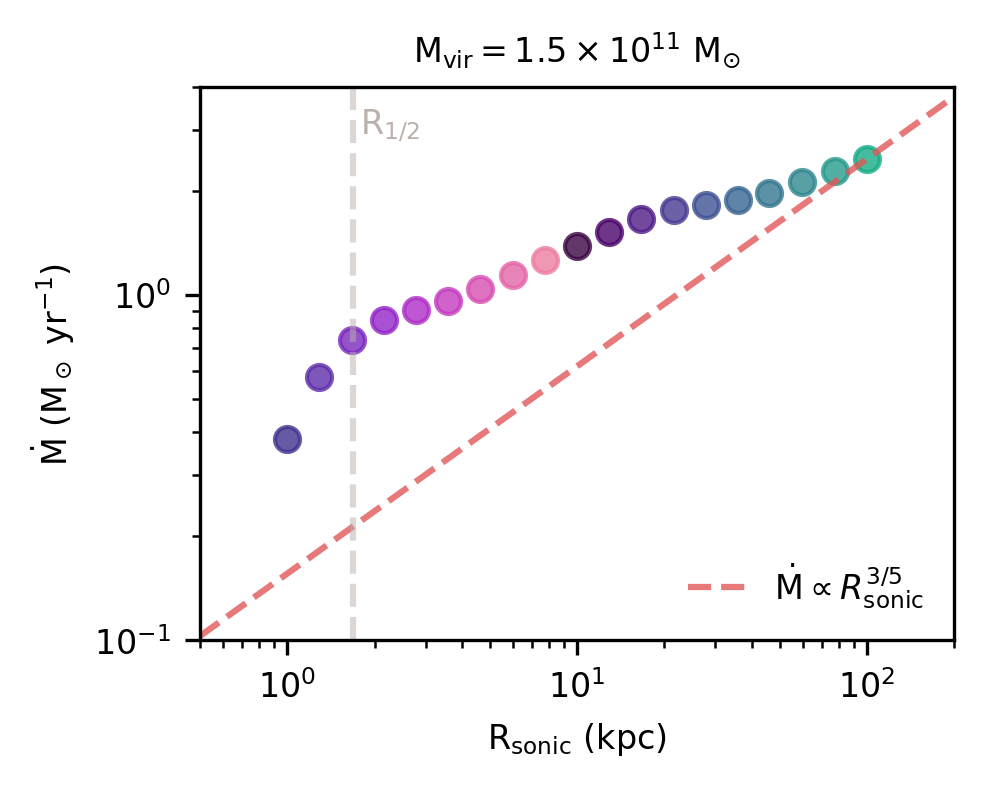

In [21]:
latexify(columns=1)
plt.figure()
ax = plt.gca()

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None and i != 6:
        # print(res.mass_flow_rate)
        plt.scatter(res.R_sonic, res.mass_flow_rate, alpha=0.8, color=colors[i])

fit_rs = np.logspace(np.log10(0.5), np.log10(200), 100)
fit = [loaded_solutions[-1].mass_flow_rate.value*(r/loaded_solutions[-1].R_sonic.value)**0.6 for r in fit_rs]
plt.plot(fit_rs, fit, c='C2', ls='--', alpha=0.8,
         label=r'$\dot{\rm M}\propto R_{\rm sonic}^{3/5}$')

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        # print(res.mass_flow_rate)
        plt.scatter(res.R_sonic, res.mass_flow_rate, alpha=0.8, color=colors2[i])

for i in range(len(temp_sonic_solutions)):
    res = temp_sonic_solutions[i]
    if res is not None:
        plt.scatter(res.R_sonic+1*un.kpc, res.mass_flow_rate, alpha=0.8, color=colors[6])
        
# plt.hlines(loaded_solutions2[-1].mass_flow_rate, loaded_solutions2[-1].R_sonic, loaded_solutions[0].R_sonic, colors='C9', linestyles='--', alpha=0.8)
# plt.hlines(loaded_solutions[0].mass_flow_rate,   loaded_solutions2[-1].R_sonic, loaded_solutions[0].R_sonic, colors='C9', linestyles='--', alpha=0.8)
plt.vlines(r_gal,0.1,4,colors='C9',ls='--',alpha=0.5)

# label the galactic radius line
plt.text(r_gal.value+0.1, 3.5, r'R$_{\rm 1/2}$', color='C9', ha='left', va='top')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(0.1, 4)
ax.set_xlim(0.5,200)
ax.set_xlabel(r'R$_{\rm sonic}$ (kpc)')
ax.set_ylabel(r'$\dot{\rm M}$ (M$_\odot$ yr$^{-1}$)')
# ax.tick_params(top=True, right=True, which="both", direction='in')
ax.legend(frameon=False, handlelength=1.8, loc='lower right')
plt.title(r'M$_{\rm vir} = 1.5 \times 10^{11}$ M$_{\odot}$')
plt.tight_layout()
plt.savefig('./plots/mdot_vs_rsonic_alt.pdf',dpi=300)
plt.show()

/tmp/ipykernel_6112/2972023540.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, handlelength=1.8)


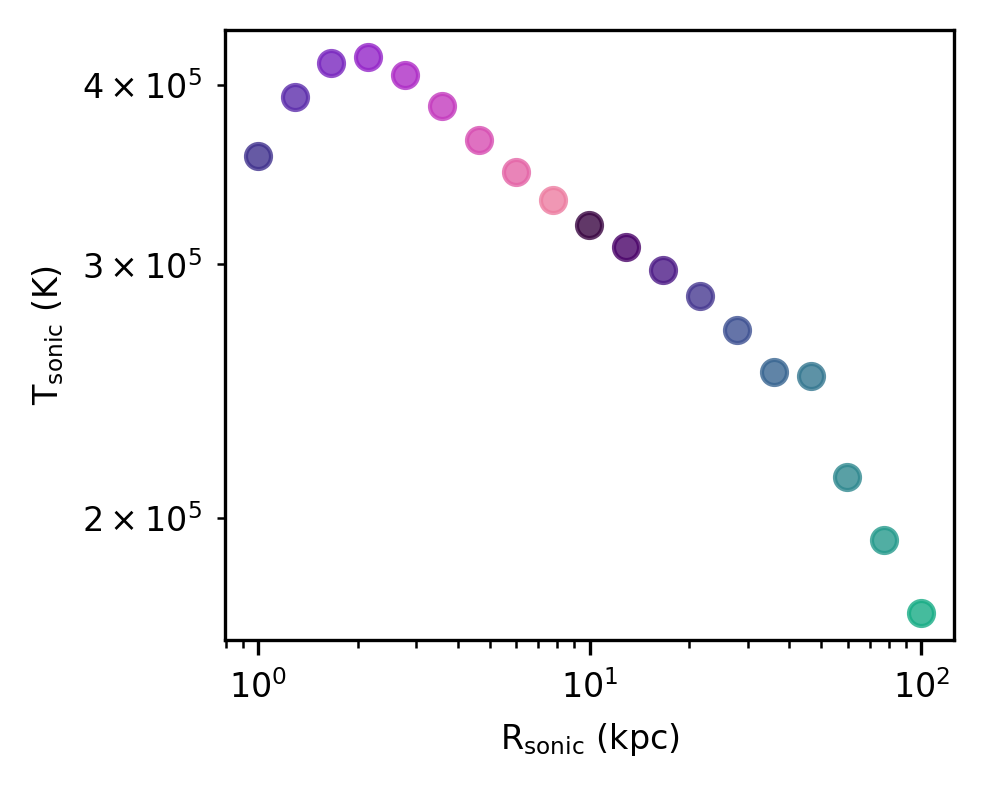

In [176]:
latexify(columns=1)
plt.figure()
ax = plt.gca()

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        T_sonic = res.Ts[mach_crossings[0]]
        plt.scatter(res.R_sonic, T_sonic, alpha=0.8, color=colors[i])

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        T_sonic = res.Ts[mach_crossings[0]]
        plt.scatter(res.R_sonic, T_sonic, alpha=0.8, color=colors2[i])

ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(0.1, 2)
# ax.set_xlim(0.5,200)
ax.set_xlabel(r'R$_{\rm sonic}$ (kpc)')
ax.set_ylabel(r'T$_{\rm sonic}$ (K)')
# ax.tick_params(top=True, right=True, which="both", direction='in')
ax.legend(frameon=False, handlelength=1.8)

plt.tight_layout()
# plt.savefig('./plots/cf_mdot.pdf',dpi=300)
plt.show()

/tmp/ipykernel_6112/4072894786.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, handlelength=1.8)


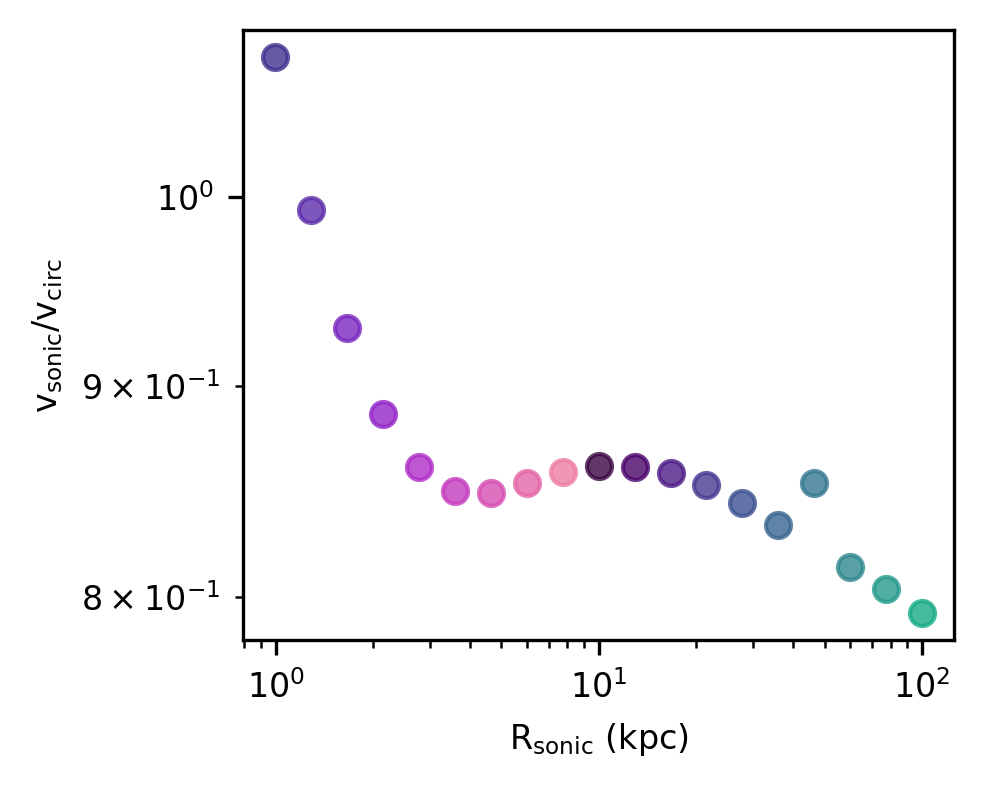

In [177]:
v_circ = combined.vc(r_ref).to('km/s')

latexify(columns=1)
plt.figure()
ax = plt.gca()

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        v_r = res.vs[mach_crossings[0]]
        cs = res.cs[mach_crossings[0]]
        v_circ = combined.vc(res.R_sonic).to('km/s')
        plt.scatter(res.R_sonic, v_r/v_circ, alpha=0.8, color=colors[i])

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        v_r = res.vs[mach_crossings[0]]
        v_circ = combined.vc(res.R_sonic).to('km/s')
        plt.scatter(res.R_sonic, v_r/v_circ, alpha=0.8, color=colors2[i])

ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(0.1, 2)
# ax.set_xlim(0.5,200)
ax.set_xlabel(r'R$_{\rm sonic}$ (kpc)')
ax.set_ylabel(r'v$_{\rm sonic}/$v$_{\rm circ}$')
# ax.tick_params(top=True, right=True, which="both", direction='in')
ax.legend(frameon=False, handlelength=1.8)

plt.tight_layout()
# plt.savefig('./plots/cf_mdot.pdf',dpi=300)
plt.show()

In [82]:
# latexify(columns=2)
# fig, axs = plt.subplots(2, 2)

# for ax in axs.flatten():
#     ax.set_xlabel(r'r (kpc)')
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.tick_params(top=True, right=True, which="both", direction='in')
#     ax.set_xlim(1,200)

#     ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
#     ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

# colors = cmr.lavender(np.linspace(0.2,0.8,len(transsonic_solutions)))
# for i in range(len(transsonic_solutions)):
#     res = transsonic_solutions[i]
#     if res is not None:
#         axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
#         axs[0, 0].set_ylabel(r'T (K)')
#         axs[0, 0].set_ylim(1e4,1e6)
        
#         axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i], 
#                        label=f'{R_sonics[i].value:.0f} kpc')
#         axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
#         axs[0, 1].set_ylim(1e-6,1e-1)
        
#         axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
#         axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i], 
#                        label=f'{R_sonics[i].value:.0f} kpc')
#         axs[1, 0].set_ylabel(r'M')
#         axs[1, 0].set_ylim(0.02,20)
        
#         axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
#         axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
#         axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
#         axs[1, 1].set_ylim(0.1,10)

#         # print(res.mass_flow_rate)

# axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
# plt.tight_layout()
# # plt.savefig('./plots/cf_sols.pdf',dpi=300)
# plt.show()